<a href="https://colab.research.google.com/github/keipero/PINNs_study/blob/main/PINN_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat

import torch
import torch.nn as nn
import torch.optim as optim

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
print(device)

cuda


In [10]:
file_path = './burgers_shock.mat'
exact_data = loadmat(file_path)

In [11]:
exact_data

{'__header__': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Wed Sep 20 16:38:22 2017',
 '__version__': '1.0',
 '__globals__': [],
 'x': array([[-1.        ],
        [-0.99215686],
        [-0.98431373],
        [-0.97647059],
        [-0.96862745],
        [-0.96078431],
        [-0.95294118],
        [-0.94509804],
        [-0.9372549 ],
        [-0.92941176],
        [-0.92156863],
        [-0.91372549],
        [-0.90588235],
        [-0.89803922],
        [-0.89019608],
        [-0.88235294],
        [-0.8745098 ],
        [-0.86666667],
        [-0.85882353],
        [-0.85098039],
        [-0.84313725],
        [-0.83529412],
        [-0.82745098],
        [-0.81960784],
        [-0.81176471],
        [-0.80392157],
        [-0.79607843],
        [-0.78823529],
        [-0.78039216],
        [-0.77254902],
        [-0.76470588],
        [-0.75686275],
        [-0.74901961],
        [-0.74117647],
        [-0.73333333],
        [-0.7254902 ],
        [-0.71764706],
        

In [12]:
x_exact = exact_data['x']
t_exact = exact_data['t']
u_exact = exact_data['usol']

In [13]:
X, T = np.meshgrid(x_exact, t_exact, indexing='ij')

<Axes: >

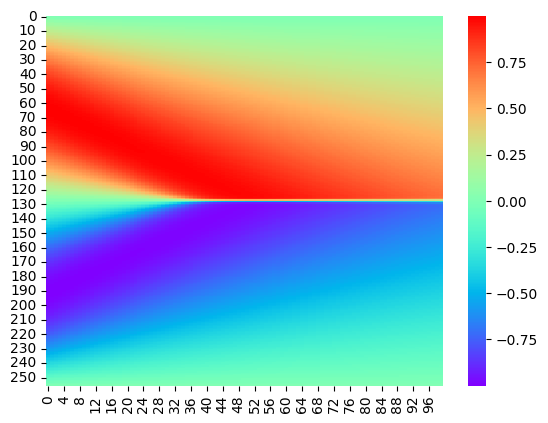

In [14]:
sns.heatmap(u_exact, cmap='rainbow')

In [15]:
criteria = nn.MSELoss()

In [16]:
def physics_informed_loss(x, t, net):
    u = net(x, t)

    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=True,
        allow_unused=True
    )[0]

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=True,
        allow_unused=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=True,
        allow_unused=True
    )[0]

    pinn_loss = u_t + u * u_x - (0.01 / np.pi) * u_xx
    zeros_t = torch.zeros(pinn_loss.size()).to(device)
    pinn_loss_ = criteria(pinn_loss, zeros_t)
    return pinn_loss_

In [17]:
def initial_condition_loss(x, t, net, u_ini):
    u = net(x, t)
    ini_condition_loss = criteria(u, u_ini)
    return ini_condition_loss

def boundary_condition_loss(x, t, net, u_bc):
    u = net(x, t)
    bc_condition_loss = criteria(u, u_bc)
    return bc_condition_loss


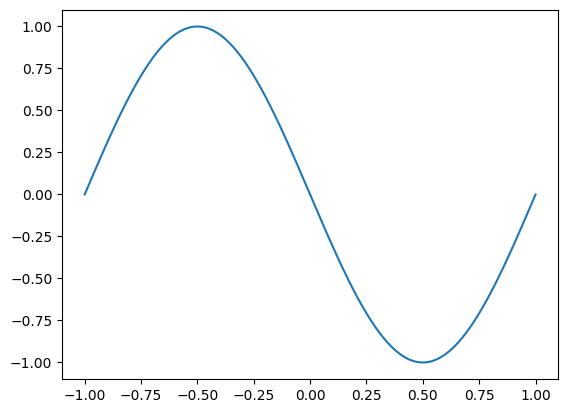

In [18]:
ini_sample_size = 2000
x_ini = np.linspace(-1, 1, ini_sample_size)
X_ini = np.zeros([ini_sample_size, 2])
X_ini[:, 0] = x_ini
u_ini = -np.sin(np.pi * x_ini)
plt.plot(x_ini, u_ini)

X_ini_t = torch.tensor(X_ini, requires_grad=True).float().to(device)
u_ini_t = torch.tensor(u_ini, requires_grad=True).float().to(device).unsqueeze(dim=1)


In [19]:
x_bc = np.array([-1.0, 1.0])
bc_sample_size = 200
t_bc = np.linspace(0, 1.0, bc_sample_size)

# x = -1.0
X_bc1 = np.zeros([bc_sample_size, 2])
X_bc1[:, 0] = -1.0
X_bc1[:, 1] = t_bc

# x = 1.0
X_bc2 = np.zeros([bc_sample_size, 2])
X_bc2[:, 0] = 1.0
X_bc2[:, 1] = t_bc

# stack
X_bc_stack = np.vstack([X_bc1, X_bc2])
u_bc_stack = np.zeros(X_bc_stack.shape[0])

X_bc_t = torch.tensor(X_bc_stack, requires_grad=True).float().to(device)
u_bc_t = torch.tensor(u_bc_stack, requires_grad=True).float().to(device).unsqueeze(dim=1)

In [20]:
# sampling point
from scipy.interpolate import RegularGridInterpolator

x_ = np.linspace(-1, 1, 100)
t_ = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_, t_, indexing='ij')
x_flat = X.flatten()
t_flat = T.flatten()

# mat の参照解 usol を、この格子の (x_flat, t_flat) 上に補間
_xe = np.asarray(x_exact).ravel()
_te = np.asarray(t_exact).ravel()
_u = np.asarray(u_exact)
interp_u = RegularGridInterpolator((_xe, _te), _u, bounds_error=False, fill_value=None)
u_exact_flat = interp_u(np.column_stack([x_flat, t_flat]))

# sampling size（残りの格子点はホールドアウト＝test 用）
sampling_size = 5000
rng = np.random.default_rng(0)
random_idx = rng.choice(np.arange(x_flat.shape[0]), size=sampling_size, replace=False)
test_idx = np.setdiff1d(np.arange(x_flat.shape[0]), random_idx)

#
# sampling
#
x_sampled = x_flat[random_idx]
t_sampled = t_flat[random_idx]
X_sampled = np.zeros([sampling_size, 2])
X_sampled[:, 0] = x_sampled
X_sampled[:, 1] = t_sampled
X_sample_t = torch.tensor(X_sampled, requires_grad=True).float().to(device)

# Train / Test：参照解との MSE を各エポックで記録するための固定テンソル
X_train_m = torch.tensor(np.stack([x_flat[random_idx], t_flat[random_idx]], axis=1), dtype=torch.float32, device=device)
u_train_ref = torch.tensor(u_exact_flat[random_idx], dtype=torch.float32, device=device).unsqueeze(1)
X_test_m = torch.tensor(np.stack([x_flat[test_idx], t_flat[test_idx]], axis=1), dtype=torch.float32, device=device)
u_test_ref = torch.tensor(u_exact_flat[test_idx], dtype=torch.float32, device=device).unsqueeze(1)


In [21]:
class PINN(torch.nn.Module):
    def __init__(self, activation='tanh'):
        super().__init__()
        self.regressor = nn.Linear(5, 1)
        self.activation = activation
        self.linear1 = self.linear(2, 5, activation=self.activation)
        self.linear2 = self.linear(5, 20, activation=self.activation)
        self.linear3 = self.linear(20, 40, activation=self.activation)
        self.linear4 = self.linear(40, 40, activation=self.activation)
        self.linear5 = self.linear(40, 40, activation=self.activation)
        self.linear6 = self.linear(40, 20, activation=self.activation)
        self.linear7 = self.linear(20, 10, activation=self.activation)
        self.linear8 = self.linear(10, 5, activation=self.activation)

    def linear(self, in_features, out_features, activation='tanh'):
        layers = [nn.Linear(in_features, out_features)]
        if activation == 'relu':
            layers.append(nn.ReLU(inplace=True))
        elif activation == 'tanh':
            layers.append(nn.Tanh())
        else:
            layers.append(nn.Sigmoid())
        net = nn.Sequential(*layers)
        return net

    def forward(self, x, t):
        inputs = torch.cat([x, t], axis=1)
        out = self.linear1(inputs)
        out = self.linear2(out)
        out = self.linear3(out)
        out = self.linear4(out)
        out = self.linear5(out)
        out = self.linear6(out)
        out = self.linear7(out)
        out = self.linear8(out)
        out = self.regressor(out)
        return out

In [22]:
net = PINN(activation='tanh').to(device)
optimizer = optim.Adam(net.parameters(), lr=0.0005)

In [23]:
loss_list = []
train_err_list = []
test_err_list = []
num_epochs = 9000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    #
    # PINN loss
    #
    x_sampled = X_sample_t[:, 0].unsqueeze(dim=-1).to(device)
    t_sampled = X_sample_t[:, 1].unsqueeze(dim=-1).to(device)
    pinn_loss = physics_informed_loss(x_sampled, t_sampled, net)
    #
    # initial loss
    #
    x_ini = X_ini_t[:, 0].unsqueeze(dim=-1).to(device)
    t_ini = X_ini_t[:, 1].unsqueeze(dim=-1).to(device)
    ini_loss = initial_condition_loss(x_ini, t_ini, net, u_ini_t)
    #
    # bc loss
    #
    x_bnd = X_bc_t[:, 0].unsqueeze(dim=-1).to(device)
    t_bnd = X_bc_t[:, 1].unsqueeze(dim=-1).to(device)
    bnd_loss = boundary_condition_loss(x_bnd, t_bnd, net, u_bc_t)

    loss = pinn_loss + ini_loss + bnd_loss
    loss.backward()
    optimizer.step()
    loss_list.append(loss.item())
    with torch.no_grad():
        u_tr = net(X_train_m[:, 0:1], X_train_m[:, 1:2])
        train_err_list.append(criteria(u_tr, u_train_ref).item())
        u_te = net(X_test_m[:, 0:1], X_test_m[:, 1:2])
        test_err_list.append(criteria(u_te, u_test_ref).item())
    if epoch % 500 == 0:
        loss_ = loss.item()
        pinn_loss_ = pinn_loss.item()
        ini_loss_ = ini_loss.item()
        bnd_loss_ = bnd_loss.item()
        print(f'epoch: {epoch:.3e}, loss:{loss_:.3e}, pinn:{pinn_loss_:.3e}, ini: {ini_loss_:.3e}, bnd:{bnd_loss_:.3e}')



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch: 0.000e+00, loss:7.479e-01, pinn:3.659e-06, ini: 6.240e-01, bnd:1.239e-01
epoch: 5.000e+02, loss:9.155e-02, pinn:3.559e-02, ini: 5.474e-02, bnd:1.225e-03
epoch: 1.000e+03, loss:2.772e-02, pinn:1.332e-02, ini: 1.426e-02, bnd:1.349e-04
epoch: 1.500e+03, loss:2.302e-02, pinn:8.434e-03, ini: 1.454e-02, bnd:4.348e-05
epoch: 2.000e+03, loss:1.624e-02, pinn:4.194e-03, ini: 1.202e-02, bnd:2.577e-05
epoch: 2.500e+03, loss:1.359e-02, pinn:2.764e-03, ini: 1.077e-02, bnd:5.273e-05
epoch: 3.000e+03, loss:3.568e-03, pinn:1.225e-03, ini: 2.335e-03, bnd:8.662e-06
epoch: 3.500e+03, loss:2.796e-03, pinn:1.683e-03, ini: 1.088e-03, bnd:2.546e-05
epoch: 4.000e+03, loss:1.273e-03, pinn:5.367e-04, ini: 7.296e-04, bnd:6.258e-06
epoch: 4.500e+03, loss:5.167e-04, pinn:3.097e-04, ini: 2.044e-04, bnd:2.634e-06
epoch: 5.000e+03, loss:1.664e-03, pinn:6.020e-04, ini: 1.058e-03, bnd:4.221e-06
epoch: 5.500e+03, loss:5.701e-04, pinn:3.054e-04, ini: 2.616e-04, bnd:3.092e-06
epoch: 6.000e+03, loss:4.397e-04, pinn:2

In [24]:
X_test = np.zeros([x_flat.shape[0], 2])
X_test[:, 0] = x_flat
X_test[:, 1] = t_flat

X_test_t = torch.tensor(X_test).float().to(device)
x_test = X_test_t[:, 0].unsqueeze(dim=-1)
t_test = X_test_t[:, 1].unsqueeze(dim=-1)
u_pred = net(x_test, t_test)

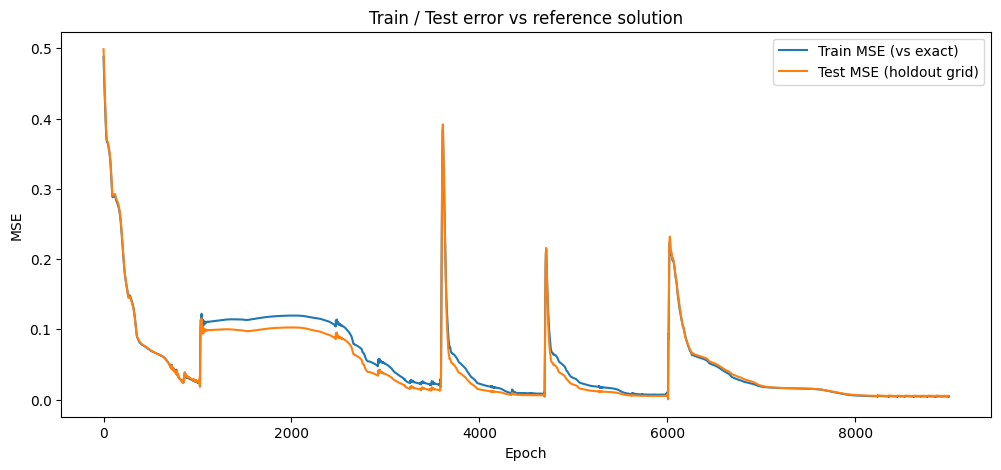

In [25]:
# Train / Test：参照解（mat の usol を格子に補間）との MSE の推移
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.arange(num_epochs), train_err_list, label='Train MSE (vs exact)')
ax.plot(np.arange(num_epochs), test_err_list, label='Test MSE (holdout grid)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Train / Test error vs reference solution')
ax.legend()
# ax.set_yscale('log')
plt.show()

In [26]:
u_pred_arr = u_pred.detach().cpu().numpy().reshape(100, 100)

<Axes: title={'center': 'Exact'}>

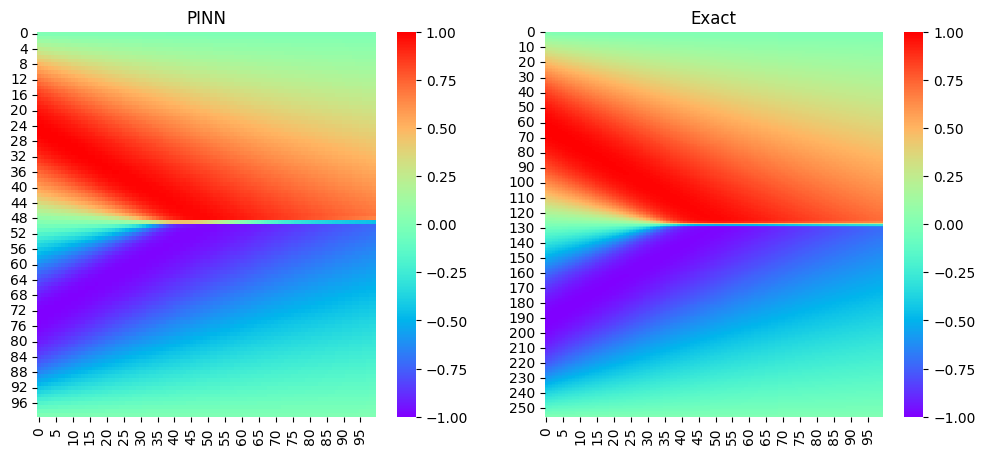

In [27]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title('PINN')
sns.heatmap(u_pred_arr, cmap='rainbow', vmin=-1, vmax=1)
plt.subplot(1, 2, 2)
plt.title('Exact')
sns.heatmap(u_exact, cmap='rainbow', vmin=-1, vmax=1)